In [1]:
import numpy as np
import threading, time
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_aer import AerSimulator
# Noise modules
from qiskit_aer.noise import NoiseModel, QuantumError, ReadoutError, depolarizing_error, pauli_error, amplitude_damping_error, phase_damping_error, phase_amplitude_damping_error, coherent_unitary_error


import toolbox_MPF as mpf

### MPF on noiseless circuit

In [2]:
# System profile

# H/J = -(XX+YY+d*ZZ)-2h*Z

nq = 8
coeff_profile = {'xx': -1, 'yy': -1, 'zz': 1.5, 'z': 0.1}
t_simul = 0.3

init_ind = 'neel'
invec = None


# observable_profile = {'zz':[[0,5],[1,4]]} 
# observable_profile = {'z':[0,1,2,3,4,5,6,7]}
observable_profile = {'z':[1,3,5,7]}

##### Numerics

In [3]:
# Setting: Numerics

ham_mat = mpf.hamiltonian_Heisenberg_mat(nq, coeff_profile)
te_mat = mpf.time_evolution_mat(ham_mat, t_simul)

In [4]:
# Initial state and observable, preparation from quantum circuit

init_circ = mpf.init_state_prep(nq, init_ind)
init_vec = mpf.state_to_vec(nq, init_circ) 

obs_mat = mpf.observable_mat(nq, observable_profile)

In [5]:
evolved_vec = te_mat@init_vec
expect_numeric = np.real(np.conjugate(evolved_vec)@obs_mat@evolved_vec)

In [6]:
expect_numeric

np.float64(0.244214644786447)

### Noisy circuit setting

#### Circuit depth dependence with fixed noise level

In [294]:
test_p = 1e-7
# test_p = 1e-6

test_ang = 5e-6

noise_mod = NoiseModel()

noise_mod.add_all_qubit_quantum_error(depolarizing_error(test_p, 2), ['cx'])
noise_mod.add_all_qubit_quantum_error(depolarizing_error(test_p, 1), ['rx', 'ry', 'rz', 'h'])

# u_x =mpf.Operator(mpf.RXGate(test_ang))
# u_y =mpf.Operator(mpf.RYGate(test_ang))
# u_z =mpf.Operator(mpf.RZGate(test_ang))

# noise_mod.add_all_qubit_quantum_error(coherent_unitary_error(u_x), ['rx'])
# noise_mod.add_all_qubit_quantum_error(coherent_unitary_error(u_y), ['ry'])
# noise_mod.add_all_qubit_quantum_error(coherent_unitary_error(u_z), ['rz'])

simulator_noisy = AerSimulator(method='density_matrix', noise_model=noise_mod)

simulator = AerSimulator()

In [295]:
output_statevector = True
# meas_basis = list(observable_profile.keys())[0]
meas_basis = 'state_vector'
invec = init_vec
optlevel = 0
n_shots = 0

observable = mpf.observable_mat(nq, observable_profile)

# test_exponents_list = [[1,2], [1,2,6], [1,2,3,10], [1,2,3,5,17], 
#                        [1,2,3,4,6,21], [1,2,3,4,5,9,34], [1,2,3,4,5,6,12,45], 
#                        [1,2,3,4,5,6,8,15,58], [1,2,3,4,5,6,7,10,18,72], [1,2,3,4,5,6,7,8,12,22,88],
#                        [1,2,3,4,5,6,7,8,10,14,27,106], [1,2,3,4,5,6,7,8,9,11,16,31,121],[1,2,3,4,5,6,7,8,9,10,13,19,37,147],
#                        [1,2,3,4,5,6,7,8,9,10,12,15,22,42,170]]

# test_exponents_list = [[1,2,6], [1,2,3,10], [1,2,3,5,15], [1, 2, 3, 4, 7, 25], [1, 2, 3, 4, 5, 9, 34], [1, 2, 3, 4, 5, 6, 12, 45]]

# test_exponents_list = [[1,2,7], [3,7], [1,2,8], [3,8], [4,9], [1,2,9], [2,3,9], [3,10], [1,2,10], [2,3,10], [1,3,10], [1,2,3,10], [1,2,3,11], [1,4,11], [1,2,4,11], [1,2,3,12], [1,3,12], [1,2,4,12], [1,3,13], [1,2,13], [1,2,5,13], [1,2,3,14], [1,2,5,14], [1,3,4,14], [1,2,3,5,15], [1,2,6,15], [1,2,3,15], [1,2,3,5,16], [1,2,3,4,16], [1,16]]

test_exp_list_dual = [[1,2,8], [1,2,10], [1,2,11], [1,2,3,13], [1,2,3,14], [1,2,3,5,15], [1,2,3,5,17]]
test_exp_list_conv = [[1,5], [1,6], [1,2,7], [1,2,8], [1,2,9], [1,2,10]]

In [296]:
err_trott_list = []
cnot_num_trott_list = []

for j in range(3,11) : 
    trotter_circ = mpf.trotter_second_XXZ(nq, init_ind, coeff_profile, t_simul, j+1, meas_basis, invec, 0)
    circ_check_trott_tran = mpf.transpile(trotter_circ, simulator, optimization_level=0)

    cnot_num_trott = circ_check_trott_tran.count_ops().get('cx', 0)
    trotter_state_dm = mpf.run_circuit_on_simulator(trotter_circ, optlevel, simulator_noisy, n_shots, invec, output_statevector)

    magnetization_trotter_noise = np.real(np.trace(trotter_state_dm@observable))
    # err_trott = mpf.rel_error(expect_numeric,magnetization_trotter_noise)
    err_trott = mpf.abs_error(expect_numeric,magnetization_trotter_noise)

    err_trott_list.append(err_trott)
    cnot_num_trott_list.append(cnot_num_trott)

In [297]:
err_conv_list = []
err_dual_list = []

num_cnot_dual_list = []
num_cnot_conv_list = []


for exp in test_exp_list_dual : 
    circ_check_MPF_dual = mpf.trotter_first_XXZ(nq, init_ind, coeff_profile, list(coeff_profile.keys()), t_simul, exp[-1], (list(observable_profile.keys()))[0], invec, 0 )
    circ_check_MPF_dual_tran = mpf.transpile(circ_check_MPF_dual, simulator, optimization_level=0)
    cnot_num_dual = circ_check_MPF_dual_tran.count_ops().get('cx', 0)

    well_MPF_dual_noise_coeff, well_MPF_dual_noise_exps, magnetization_well_MPF_dual_noise = mpf.MPF_dual(nq, init_ind, coeff_profile, t_simul, exp, observable_profile, simulator_noisy, optlevel, n_shots, invec, output_statevector, 0 )
    # err_dual = mpf.rel_error(expect_numeric,magnetization_well_MPF_dual_noise)
    err_dual = mpf.abs_error(expect_numeric,magnetization_well_MPF_dual_noise)

    err_dual_list.append(err_dual)
    num_cnot_dual_list.append(cnot_num_dual)

for exp in test_exp_list_conv :  
    circ_check_MPF_conven = mpf.trotter_second_XXZ(nq, init_ind, coeff_profile, t_simul, exp[-1], (list(observable_profile.keys()))[0], invec, 0 )
    circ_check_MPF_conven_tran = mpf.transpile(circ_check_MPF_conven, simulator, optimization_level=0)
    cnot_num_conven = circ_check_MPF_conven_tran.count_ops().get('cx', 0)

    well_MPF_conven_noise_coeff, well_MPF_conven_noise_exps, magnetization_well_MPF_conven_noise = mpf.MPF_conventional(nq, init_ind, coeff_profile, t_simul, exp, observable_profile, simulator_noisy, optlevel, n_shots, invec, output_statevector, 0 )
    # err_conv = mpf.rel_error(expect_numeric,magnetization_well_MPF_conven_noise)
    err_conv = mpf.abs_error(expect_numeric,magnetization_well_MPF_conven_noise)
    

    err_conv_list.append(err_conv)
    num_cnot_conv_list.append(cnot_num_conven)
    

In [292]:
err_trott_list, err_conv_list, err_dual_list

([np.float64(0.019128489791501085),
  np.float64(0.011834513431270427),
  np.float64(0.008066898071163453),
  np.float64(0.005860166754861701),
  np.float64(0.0044538111230981725),
  np.float64(0.0035013160791524667),
  np.float64(0.0028258119206210353),
  np.float64(0.002329123570888797)],
 [np.float64(0.007812193109221571),
  np.float64(0.005201089411469739),
  np.float64(0.004481797679134286),
  np.float64(0.0034117558515748825),
  np.float64(0.0026851500020825814),
  np.float64(0.0021688823806920443)],
 [np.float64(0.0005395093985083865),
  np.float64(0.0003391830011623409),
  np.float64(0.0002788010691410492),
  np.float64(0.00010697548253899014),
  np.float64(9.197867190477438e-05),
  np.float64(1.2538599454964272e-05),
  np.float64(9.729945477487956e-06)])

In [ ]:
############################################
############### Data Save ##################
############################################

time_index = t_simul

mpf.save_pickle('data_pf_00_{:.0e}_{:.0e}'.format(time_index ,test_p), {'system': {'nq' : 8,
'coeff_profile' : coeff_profile, 'initial_state' : init_ind, 
't_simul' : t_simul}, 'noise' : {'depolarizing' : ['cx'], 'p' : test_p}, 'obserbavle' : observable_profile,'exponents' : range(3,11), 'error': 'rel' }, [cnot_num_trott_list, err_trott_list])

mpf.save_pickle('data_mpf_conven_00_{:.0e}_{:.0e}'.format(time_index ,test_p), {'system': {'nq' : 8,
'coeff_profile' : coeff_profile, 'initial_state' : init_ind, 
't_simul' : t_simul}, 'noise' : {'depolarizing' : ['cx'], 'p' : test_p}, 'obserbavle' : observable_profile, 'exponents' : test_exp_list_conv, 'error': 'rel' }, [num_cnot_conv_list, err_conv_list])

mpf.save_pickle('data_mpf_dual_00_{:.0e}_{:.0e}'.format(time_index ,test_p), {'system': {'nq' : 8,
'coeff_profile' : coeff_profile, 'initial_state' : init_ind, 
't_simul' : t_simul}, 'noise' : {'depolarizing' : ['cx'], 'p' : test_p}, 'obserbavle' : observable_profile, 'exponents' : test_exp_list_dual, 'error': 'rel' }, [num_cnot_dual_list, err_dual_list])

In [ ]:
############################################
############### Data Load ##################
############################################

t_load=0.3

load_p1=1e-8
load_p2=1e-7
load_p3=4e-7
load_p4=7e-7
load_p5=1e-6

info_pf, data_pf1 = mpf.load('data_pf_01_{:.0e}_{:.0e}.pkl'.format(t_load, load_p1)) 
info_mpf_conv, data_mpf_conv1 = mpf.load('data_mpf_conven_01_{:.0e}_{:.0e}.pkl'.format(t_load, load_p1)) 
info_mpf_dual, data_mpf_dual1 = mpf.load('data_mpf_dual_01_{:.0e}_{:.0e}.pkl'.format(t_load, load_p1)) 

info_pf, data_pf2 = mpf.load('data_pf_01_{:.0e}_{:.0e}.pkl'.format(t_load, load_p2)) 
info_mpf_conv, data_mpf_conv2 = mpf.load('data_mpf_conven_01_{:.0e}_{:.0e}.pkl'.format(t_load, load_p2)) 
info_mpf_dual, data_mpf_dual2 = mpf.load('data_mpf_dual_01_{:.0e}_{:.0e}.pkl'.format(t_load, load_p2)) 

info_pf, data_pf3 = mpf.load('data_pf_01_{:.0e}_{:.0e}.pkl'.format(t_load, load_p3)) 
info_mpf_conv, data_mpf_conv3 = mpf.load('data_mpf_conven_01_{:.0e}_{:.0e}.pkl'.format(t_load, load_p3)) 
info_mpf_dual, data_mpf_dual3 = mpf.load('data_mpf_dual_01_{:.0e}_{:.0e}.pkl'.format(t_load, load_p3)) 

info_pf, data_pf4 = mpf.load('data_pf_01_{:.0e}_{:.0e}.pkl'.format(t_load, load_p4)) 
info_mpf_conv, data_mpf_conv4 = mpf.load('data_mpf_conven_01_{:.0e}_{:.0e}.pkl'.format(t_load, load_p4)) 
info_mpf_dual, data_mpf_dual4 = mpf.load('data_mpf_dual_01_{:.0e}_{:.0e}.pkl'.format(t_load, load_p4)) 

info_pf, data_pf5 = mpf.load('data_pf_01_{:.0e}_{:.0e}.pkl'.format(t_load, load_p5)) 
info_mpf_conv, data_mpf_conv5 = mpf.load('data_mpf_conven_01_{:.0e}_{:.0e}.pkl'.format(t_load, load_p5)) 
info_mpf_dual, data_mpf_dual5 = mpf.load('data_mpf_dual_01_{:.0e}_{:.0e}.pkl'.format(t_load, load_p5)) 

cnot_num_trott_list, err_trott_list = data_pf1
num_cnot_conv_list, err_conv_list = data_mpf_conv1
num_cnot_dual_list, err_dual_list = data_mpf_dual1

cnot_num_trott_list, err_trott_list2 = data_pf2
num_cnot_conv_list, err_conv_list2 = data_mpf_conv2
num_cnot_dual_list, err_dual_list2 = data_mpf_dual2

cnot_num_trott_list, err_trott_list3 = data_pf3
num_cnot_conv_list, err_conv_list3 = data_mpf_conv3
num_cnot_dual_list, err_dual_list3 = data_mpf_dual3

cnot_num_trott_list, err_trott_list4 = data_pf4
num_cnot_conv_list, err_conv_list4 = data_mpf_conv4
num_cnot_dual_list, err_dual_list4 = data_mpf_dual4

cnot_num_trott_list, err_trott_list5 = data_pf5
num_cnot_conv_list, err_conv_list5 = data_mpf_conv5
num_cnot_dual_list, err_dual_list5 = data_mpf_dual5

test_exp_list_conv = info_mpf_conv['exponents']
test_exp_list_dual = info_mpf_dual['exponents']

In [8]:
info_mpf_conv

{'system': {'nq': 8,
  'coeff_profile': {'xx': -1, 'yy': -1, 'zz': 1.5, 'z': 0.1},
  'initial_state': 'neel',
  't_simul': 0.3},
 'noise': {'depolarizing': ['cx'], 'p': 1e-06},
 'obserbavle': {'z': [1, 3, 5, 7]},
 'exponents': [[1, 5], [1, 6], [1, 2, 7], [1, 2, 8], [1, 2, 9], [1, 2, 10]],
 'error': 'rel'}

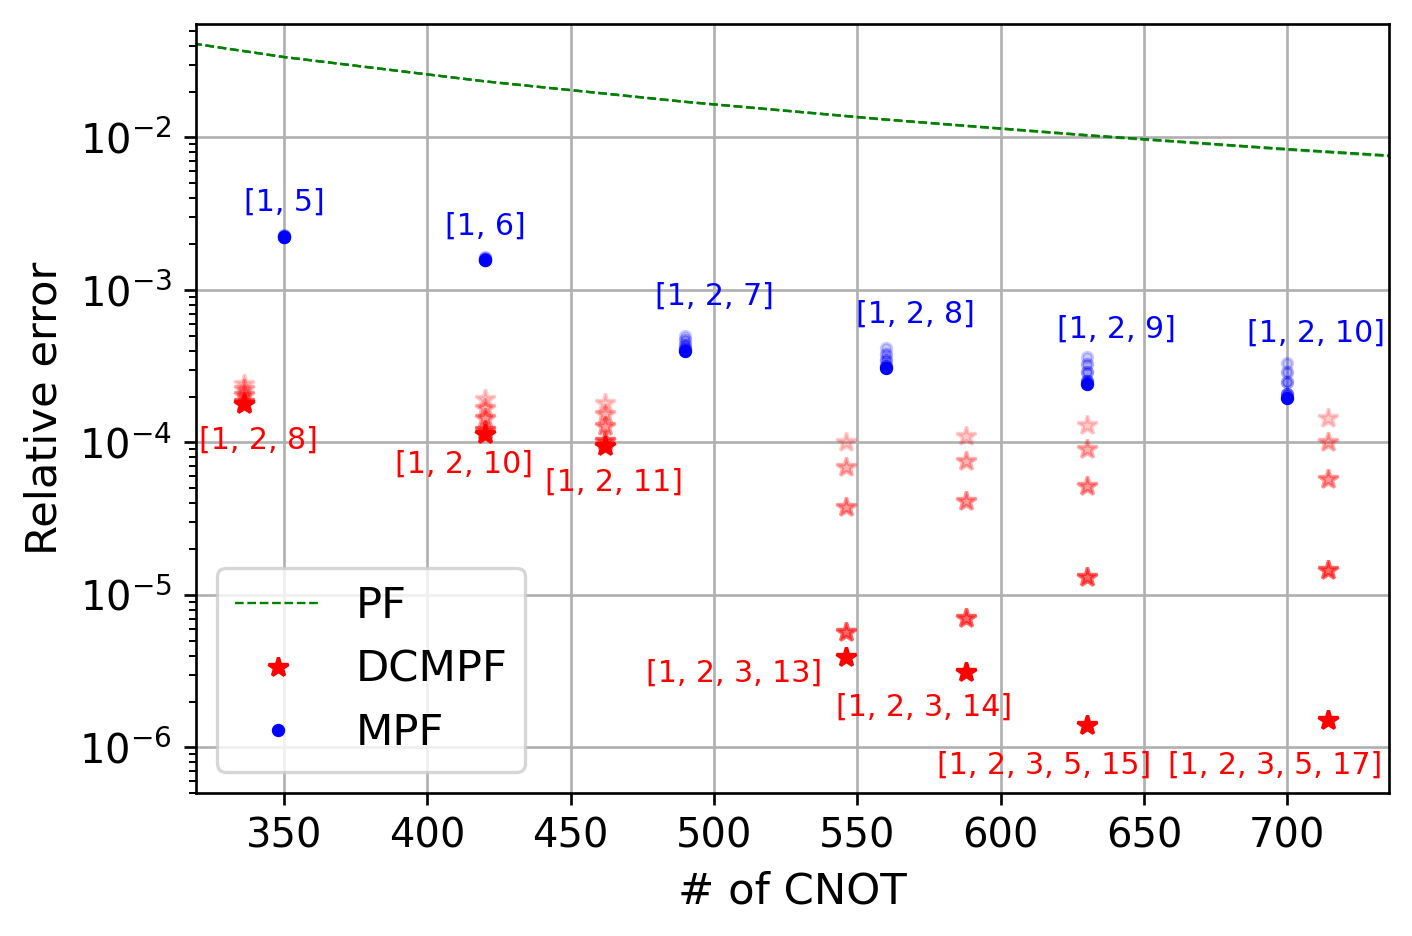

In [ ]:
x_1 = num_cnot_conv_list
y_1 = err_conv_list

x_2 = num_cnot_dual_list
y_2 = err_dual_list

x_3 = cnot_num_trott_list
y_3 = err_trott_list

y_12 = err_conv_list2
y_22 = err_dual_list2
y_32 = err_trott_list2

y_13 = err_conv_list3
y_23 = err_dual_list3
y_33 = err_trott_list3

y_14 = err_conv_list4
y_24 = err_dual_list4
y_34 = err_trott_list4

y_15 = err_conv_list5
y_25 = err_dual_list5
y_35 = err_trott_list5

fig, ax = plt.subplots(figsize=(6,4), dpi=240)
ax.plot(x_3, y_3, linestyle = '--', linewidth = '0.7',label='PF', color = 'green')
ax.plot(x_2, y_2, linestyle = 'none', marker = '*', label='DCMPF', color = 'red')
ax.plot(x_1, y_1, linestyle = 'none', marker = '.', label='MPF', color = 'blue')

ax.plot(x_3, y_32, linestyle = '--', linewidth = '0.7', color = 'green', alpha =0.6)
ax.plot(x_2, y_22, linestyle = 'none', marker = '*', color = 'red', alpha =0.6)
ax.plot(x_1, y_12, linestyle = 'none', marker = '.',  color = 'blue', alpha =0.6)

ax.plot(x_3, y_33, linestyle = '--', linewidth = '0.7', color = 'green', alpha =0.4)
ax.plot(x_2, y_23, linestyle = 'none', marker = '*', color = 'red', alpha =0.4)
ax.plot(x_1, y_13, linestyle = 'none', marker = '.', color = 'blue', alpha =0.4)

ax.plot(x_3, y_34, linestyle = '--', linewidth = '0.7', color = 'green', alpha =0.3)
ax.plot(x_2, y_24, linestyle = 'none', marker = '*', color = 'red', alpha =0.3)
ax.plot(x_1, y_14, linestyle = 'none', marker = '.',  color = 'blue', alpha =0.3)

ax.plot(x_3, y_35, linestyle = '--', linewidth = '0.7', color = 'green', alpha =0.2)
ax.plot(x_2, y_25, linestyle = 'none', marker = '*', color = 'red', alpha =0.2)
ax.plot(x_1, y_15, linestyle = 'none', marker = '.', color = 'blue', alpha =0.2)

ax.set_ylim(bottom = 5e-7)
# ax.set_ylim(top = np.max(err_conv_list)*1.1)

ax.set_yscale('log')

ax.set_xlim(left = np.min(num_cnot_dual_list)*0.95)
ax.set_xlim(right = np.max(num_cnot_dual_list)*1.03)

ax.set_xlabel("# of CNOT", fontsize=13)
ax.set_ylabel("Relative error", fontsize=13)


xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

x_off_text = -0.07 * (xmax-xmin)
y_off_text = 0.02 * (ymax-ymin)

disp_list_1 = [(-40, 20),(-40, 20),(-30, 40),(-30, 40),(-30, 40),(-40, 50)]
for x, y, label, ii in zip(num_cnot_conv_list, err_conv_list, test_exp_list_conv, disp_list_1):
    ax.annotate(
        str(label),
        xy=(x, y),                 # data coordinates
        xytext=ii,             # +5 px right, +5 px up
        textcoords='offset pixels',
        fontsize=9,
        color='blue',
        ha='left',
        va='bottom',
    )

disp_list_2 = [(-45, -50),(-90, -45),(-60, -50),(-200, -30),(-130, -50),(-150, -55),(-160, -60)]
for ii in range(len(num_cnot_dual_list)) :
    ax.annotate(str(test_exp_list_dual[ii]),
        xy=(num_cnot_dual_list[ii], err_dual_list[ii]),
        xytext=disp_list_2[ii],             # tweak per taste
        textcoords='offset pixels',
        fontsize=9,
        color='red',
        ha='left',
        va='bottom',
    )

ax.tick_params(axis='both', which='major', labelsize=12) 

ax.legend(fontsize=13)
ax.grid(True)



plt.tight_layout()
# plt.savefig('plt_01_merge.png', dpi=240)
plt.show()